In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from pybaseball import batting_stats
import logging
import tensorflow as tf
tf.get_logger().setLevel(logging.FATAL)  # suppress TF warnings

# --- Load data ---
raw_2021 = batting_stats(2021)
raw_2022 = batting_stats(2022)
raw_2023 = batting_stats(2023)
raw_2024 = batting_stats(2024)
raw_2025 = batting_stats(2025)

# --- Combine ---
raw_data = pd.concat([raw_2021, raw_2022, raw_2023, raw_2024, raw_2025])

# --- Select columns ---
df = raw_data[["Season", "Name", "Team", "Pos", "Age", "PA", 
               "AVG", "OBP", "SLG", "xBA", "K%", "Contact%", 
               "EV", "Barrel%", "HardHit%"]]

# --- Filter 300+ PA ---
df = df[df['PA'] >= 300].copy()

#save data
#raw_data.to_csv("C:/Users/Andrew/baseball/data/batting_stats_raw_2021_2025.csv", index=False)
#df.to_csv("C:/Users/Andrew/baseball/data/batting_stats_filtered_2021_2025.csv", index=False)

print(f"Total rows: {len(df)}")
print(f"Total players: {df['Name'].nunique()}")
print(f"Seasons: {sorted(df['Season'].unique())}")

Total rows: 670
Total players: 286
Seasons: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [3]:
# --- Sort by player and season ---
df = df.sort_values(['Name', 'Season']).reset_index(drop=True)

# --- Create next year AVG target ---
df['AVG_next'] = df.groupby('Name')['AVG'].shift(-1)

# --- Split into training and prediction sets ---
model_df = df[df['AVG_next'].notna()].copy()  # has a next year AVG
df_2025 = df[df['Season'] == 2025].copy()     # predict these

# --- Define features and target ---
features_xba = ['xBA']
target = 'AVG_next'

X = model_df[features_xba].values  # raw, no standardization
y = model_df[target].values
X_2025 = df_2025[features_xba].values

print(f"Training rows: {len(model_df)}")
print(f"Players to predict: {len(df_2025)}")
print(f"y mean: {y.mean():.3f}, y std: {y.std():.3f}")
print(model_df[['Name', 'Season', 'xBA', 'AVG_next']].head(10))

Training rows: 384
Players to predict: 145
y mean: 0.260, y std: 0.026
               Name  Season    xBA  AVG_next
1       Aaron Judge    2021  0.302     0.311
2       Aaron Judge    2022  0.304     0.322
3       Aaron Judge    2024  0.305     0.331
6      Adam Frazier    2021  0.286     0.238
9   Adley Rutschman    2023  0.289     0.250
11    Adolis Garcia    2021  0.216     0.250
12    Adolis Garcia    2022  0.242     0.245
13    Adolis Garcia    2023  0.245     0.224
14    Adolis Garcia    2024  0.223     0.227
17        Alec Bohm    2022  0.287     0.274


In [4]:
with pm.Model() as model_xba:
    # --- Data containers ---
    X_data = pm.Data('X_data', X)
    y_data = pm.Data('y_data', y)
    
    # --- Priors ---
    alpha = pm.Normal('alpha', mu=y.mean(), sigma=y.std())  # empirical Bayes
    betas = pm.Normal('betas', mu=0, sigma=1.0, shape=1)    # loose prior, raw scale
    sigma = pm.HalfNormal('sigma', sigma=y.std())           # empirical Bayes on noise too
    
    # --- Linear model ---
    mu = alpha + (X_data * betas).sum(axis=1)
    
    # --- Likelihood ---
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y_data)
    
    # --- Sample ---
    trace = pm.sample(1000, tune=2000, chains=4, target_accept=0.9, cores=4)

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 65 seconds.


In [5]:
az.summary(trace, var_names=['alpha', 'betas', 'sigma'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.139,0.012,0.115,0.161,0.000,0.000,1374.0,1436.0,1.0
betas[0],0.473,0.047,0.386,0.564,0.001,0.001,1372.0,1436.0,1.0
sigma,0.023,0.001,0.021,0.025,0.000,0.000,1521.0,1830.0,1.0


In [ ]:
for i, feature in enumerate(features_xba):
    row = az.summary(trace, var_names=['betas']).iloc[i]
    f"{feature:12s}  mean={row['mean']:+.4f}  hdi=[{row['hdi_3%']:+.4f}, {row['hdi_97%']:+.4f}]"

xBA           mean=+0.4730  hdi=[+0.3860, +0.5640]


In [9]:
with model_xba:
    pm.set_data({
        'X_data': X_2025,
        'y_data': np.zeros(len(df_2025))  # dummy y
    })
    ppc_2025 = pm.sample_posterior_predictive(trace)

# extract predictions
pred_samples = ppc_2025.posterior_predictive['y_obs'].values.reshape(-1, len(df_2025))

df_2025['predicted_AVG'] = pred_samples.mean(axis=0)
df_2025['pred_hdi_low'] = np.percentile(pred_samples, 3, axis=0)
df_2025['pred_hdi_high'] = np.percentile(pred_samples, 97, axis=0)

df_2025[['Name', 'xBA', 'AVG', 'predicted_AVG', 'pred_hdi_low', 'pred_hdi_high']]\
      .sort_values('predicted_AVG', ascending=False)\
      .head(20)

Sampling: [y_obs]


Output()

,Name,xBA,AVG,predicted_AVG,pred_hdi_low,pred_hdi_high
4,Aaron Judge,0.300,0.331,0.280462,0.237688,0.323845
627,Vladimir Guerrero Jr.,0.300,0.292,0.280254,0.237171,0.323705
70,Bo Bichette,0.295,0.311,0.278257,0.235313,0.321152
491,Nico Hoerner,0.292,0.297,0.277501,0.234065,0.320396
211,George Springer,0.291,0.309,0.276152,0.231979,0.318996
347,Juan Soto,0.288,0.263,0.275031,0.230364,0.316584
658,Yandy Diaz,0.286,0.300,0.274509,0.231716,0.318546
401,Luis Arraez,0.287,0.292,0.274491,0.232263,0.317301
368,Ketel Marte,0.285,0.283,0.274188,0.230606,0.319232
326,Jose Ramirez,0.284,0.283,0.273364,0.229895,0.316877


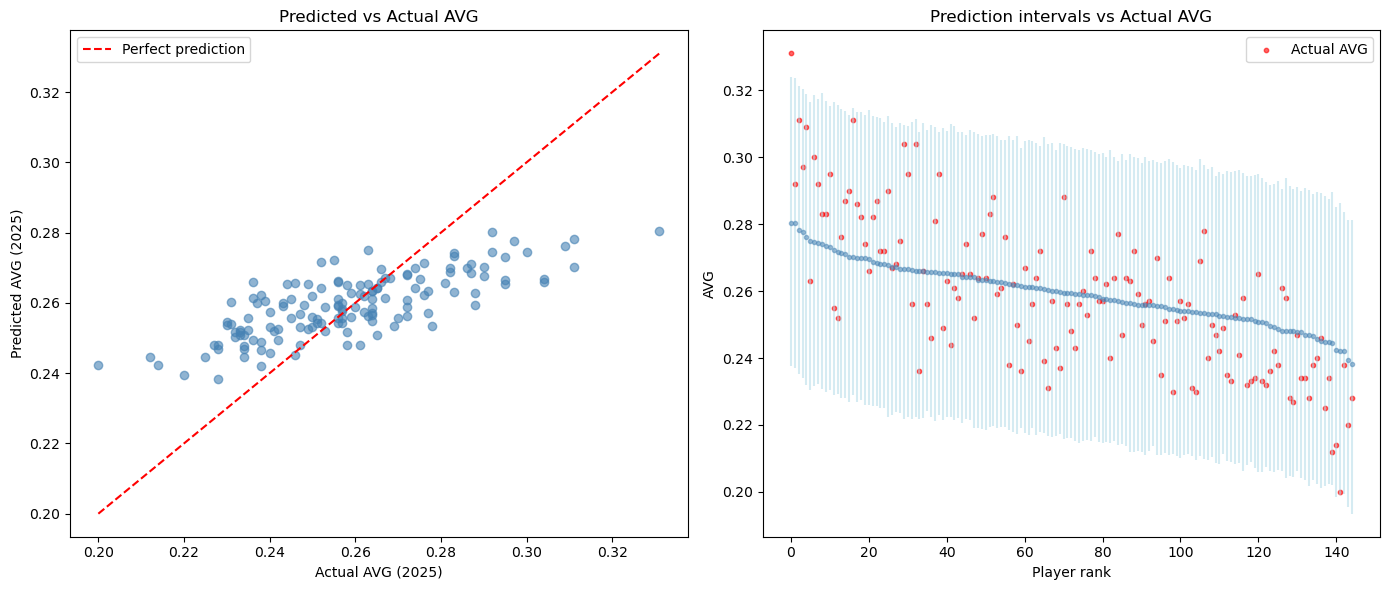

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Predicted vs Actual ---
ax = axes[0]
ax.scatter(df_2025['AVG'], df_2025['predicted_AVG'], alpha=0.6, color='steelblue')

min_val = min(df_2025['AVG'].min(), df_2025['predicted_AVG'].min())
max_val = max(df_2025['AVG'].max(), df_2025['predicted_AVG'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')

ax.set_xlabel('Actual AVG (2025)')
ax.set_ylabel('Predicted AVG (2025)')
ax.set_title('Predicted vs Actual AVG')
ax.legend()

# --- Plot 2: Prediction intervals ---
ax = axes[1]
df_sorted = df_2025.sort_values('predicted_AVG', ascending=False).reset_index(drop=True)

ax.errorbar(
    range(len(df_sorted)),
    df_sorted['predicted_AVG'],
    yerr=[
        df_sorted['predicted_AVG'] - df_sorted['pred_hdi_low'],
        df_sorted['pred_hdi_high'] - df_sorted['predicted_AVG']
    ],
    fmt='o', markersize=3, alpha=0.5, color='steelblue', ecolor='lightblue'
)
ax.scatter(range(len(df_sorted)), df_sorted['AVG'], 
           color='red', s=10, alpha=0.6, label='Actual AVG')

ax.set_xlabel('Player rank')
ax.set_ylabel('AVG')
ax.set_title('Prediction intervals vs Actual AVG')
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import root_mean_squared_error
import scipy.stats as stats

# --- RMSE ---
rmse = root_mean_squared_error(df_2025['AVG'], df_2025['predicted_AVG'])
print(f"RMSE: {rmse:.4f}")

# --- Correlation ---
corr, pval = stats.pearsonr(df_2025['AVG'], df_2025['predicted_AVG'])
print(f"Pearson correlation: {corr:.4f}")
print(f"P-value: {pval:.4f}")

# --- Mean bias (are we systematically over or under predicting?) ---
bias = (df_2025['predicted_AVG'] - df_2025['AVG']).mean()
print(f"Mean bias: {bias:.4f}")

# --- Coverage (what % of actual AVGs fall inside the HDI?) ---
coverage = ((df_2025['AVG'] >= df_2025['pred_hdi_low']) & 
            (df_2025['AVG'] <= df_2025['pred_hdi_high'])).mean()
print(f"HDI coverage: {coverage:.1%}")

RMSE: 0.0167
Pearson correlation: 0.7679
P-value: 0.0000
Mean bias: 0.0009
HDI coverage: 99.3%


Text(0.5, 1.0, 'Residuals vs Predicted')

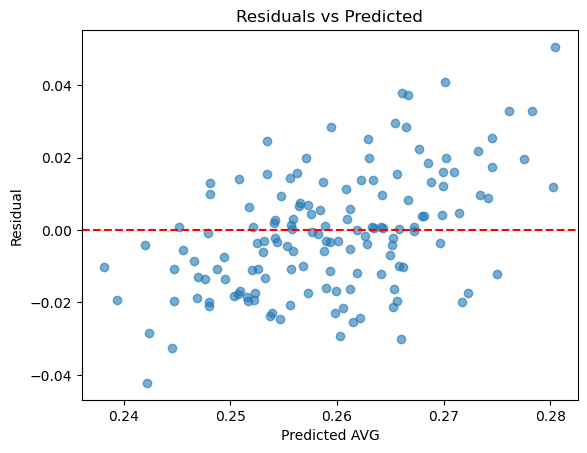

In [12]:
residuals = df_2025['AVG'] - df_2025['predicted_AVG']
plt.scatter(df_2025['predicted_AVG'], residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted AVG')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')

Text(0.5, 1.0, 'Residual Distribution')

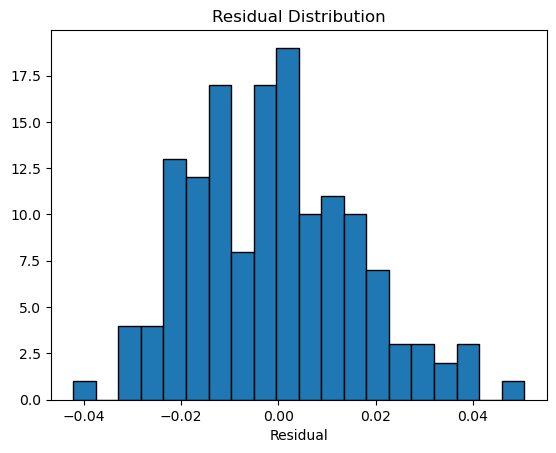

In [14]:
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel('Residual')
plt.title('Residual Distribution')

Text(0.5, 1.0, 'Q-Q Plot of Residuals')

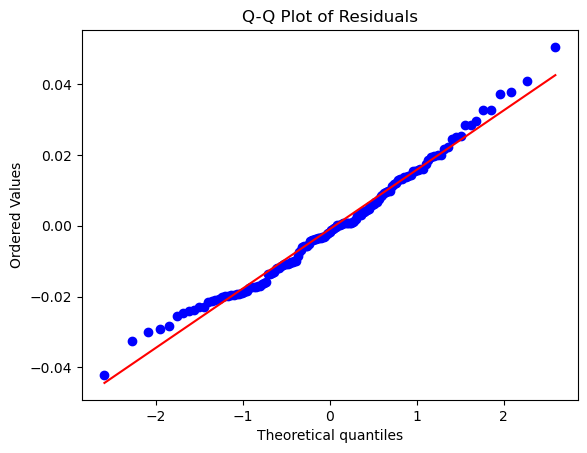

In [15]:
import scipy.stats as stats
stats.probplot(residuals, plot=plt)
plt.title('Q-Q Plot of Residuals')

Sampling: [y_obs]


Output()

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


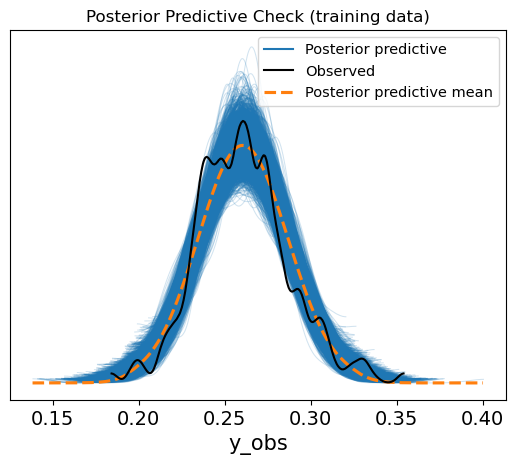

In [16]:
# regenerate ppc on training data
with model_xba:
    pm.set_data({
        'X_data': X,
        'y_data': y
    })
    ppc_train = pm.sample_posterior_predictive(trace)

# now plot against real observed values
az.plot_ppc(ppc_train)
plt.title('Posterior Predictive Check (training data)')
plt.show()

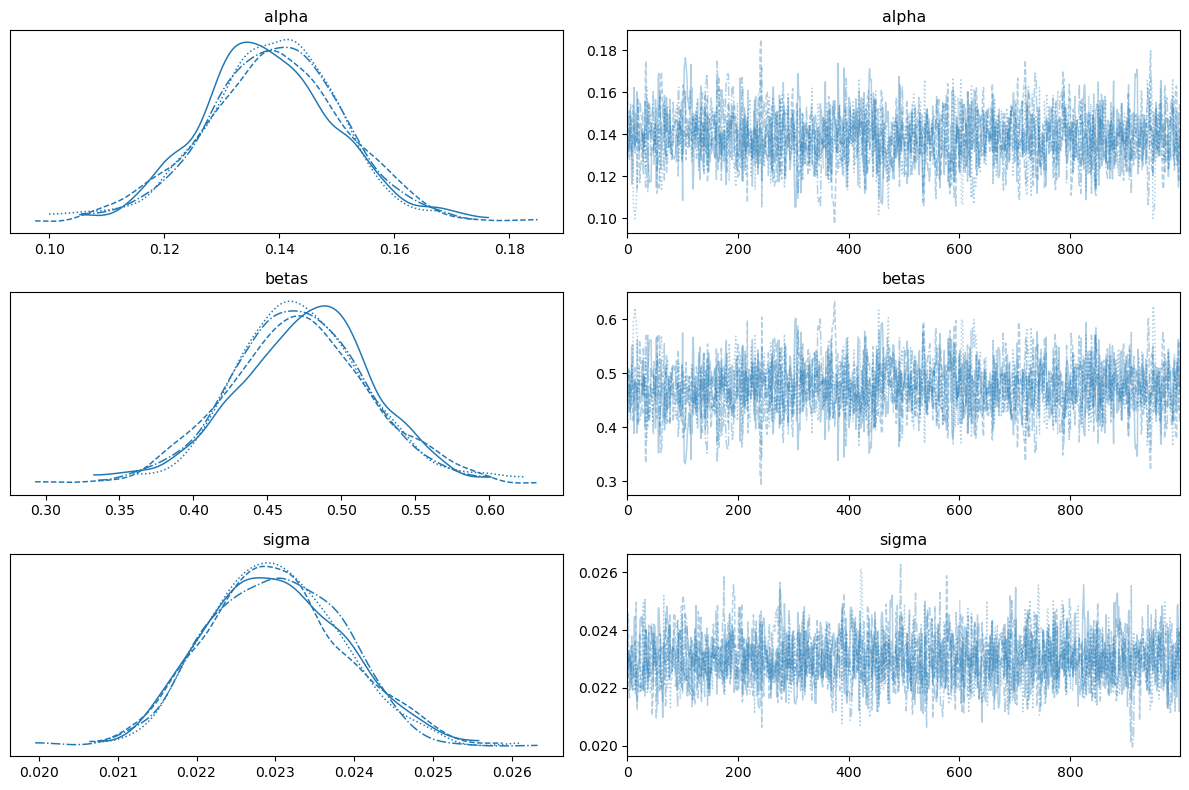

In [17]:
az.plot_trace(trace, var_names=['alpha', 'betas', 'sigma'], figsize=(12, 8))
plt.tight_layout()
plt.show()